# PCA Deletion Similarity Signals

Analyze sweep similarity curves by layer and deleted PCA dimensions.

In [1]:
EXPERIMENT = "pca_deletion"
RUN_ID = None  # e.g. "pca_deletion_fast_run"; None selects the newest run directory
METRICS_TO_PLOT = ["softmax_rwka", "rbf_rwka", "cka_rbf", "mutual_knn", "cknna"]
REF_LAYER = None
SAMPLE_PARAM = 1.0

In [2]:
import pathlib
import sys

start = pathlib.Path.cwd().resolve()
for candidate in [start, *start.parents]:
    if (candidate / "paths.py").exists():
        REPO_DIR = candidate
        break
else:
    raise RuntimeError("Could not find repo root containing paths.py")

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from paths import resources_path
from experiments.sweep_analysis import (
    add_experiment_preset_columns,
    entries_to_dataframe,
    list_sweep_metrics,
    load_sweep_entries,
    sample_similarity_at_param,
    save_preset_plots,
)

def latest_run(results_root):
    runs = [path for path in results_root.iterdir() if path.is_dir()]
    if not runs:
        raise FileNotFoundError(f"No run directories found under {results_root}")
    return max(runs, key=lambda path: path.stat().st_mtime)

results_root = resources_path / "results" / EXPERIMENT
results_path = results_root / RUN_ID if RUN_ID else latest_run(results_root)
sweeps_dir = results_path / "sweeps"
figures_dir = results_path / "figures" / "sweep_signals"
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Results path: {results_path}")
print(f"Sweeps path: {sweeps_dir}")
print(f"Figures path: {figures_dir}")

Results path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001
Sweeps path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/sweeps
Figures path: /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals


In [3]:
available_metrics = list_sweep_metrics(sweeps_dir)
metrics = [metric for metric in METRICS_TO_PLOT if metric in available_metrics]
if not metrics:
    metrics = available_metrics
print(f"Available sweep metrics: {available_metrics}")
print(f"Plotting metrics: {metrics}")

entries = load_sweep_entries(sweeps_dir)
sweep_df = entries_to_dataframe(entries)
sweep_df = add_experiment_preset_columns(sweep_df, EXPERIMENT, ref_layer=REF_LAYER)
print(sweep_df.shape)
print(sorted(sweep_df.columns))
sweep_df.head()

Available sweep metrics: ['cka_rbf', 'mutual_knn', 'softmax_rwka']
Plotting metrics: ['softmax_rwka', 'cka_rbf', 'mutual_knn']
(11205, 32)
['CKA', 'PWCCA', 'Procrustes', 'architecture1', 'architecture2', 'cka_rbf', 'cka_rbf_auc', 'cknna', 'dataset1', 'dataset2', 'dims_deleted', 'dims_kept', 'layer1', 'layer2', 'mean_cca_corr', 'mean_sq_cca_corr', 'metric', 'metric_auc', 'mutual_knn', 'mutual_knn_auc', 'param_name', 'param_values', 'path', 'same_seed', 'scores', 'seed1', 'seed2', 'seed_mode', 'softmax_rwka', 'softmax_rwka_auc', 'step1', 'step2']


,path,metric,metric_auc,param_name,param_values,scores,dataset1,architecture1,seed1,step1,...,Procrustes,mutual_knn,mutual_knn_auc,cka_rbf,cka_rbf_auc,cknna,softmax_rwka,softmax_rwka_auc,same_seed,seed_mode
0,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.8651124405182299, 0.8712930663506917, 0.877...","[0.9999999999998667, 0.9999999999998658, 0.999...",mnli_matched_100,base,1,2000000,...,-4.440892e-16,0.000000,0.000000,1.731948e-13,1.616485e-13,NaN,NaN,NaN,True,same_seed
1,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.8642225074509047, 0.8704319427578641, 0.876...","[0.9999950688327685, 0.9999950879103824, 0.999...",mnli_matched_100,base,1,2000000,...,2.558510e-03,0.003190,0.002894,4.610350e-06,4.700670e-06,NaN,NaN,NaN,True,same_seed
2,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.8627363060103085, 0.8690004800968767, 0.875...","[0.9999650945453027, 0.9999652002207954, 0.999...",mnli_matched_100,base,1,2000000,...,9.219258e-03,0.009115,0.007542,3.306699e-05,3.358912e-05,NaN,NaN,NaN,True,same_seed
3,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.8602837767653513, 0.8666448896871239, 0.873...","[0.9998366722398986, 0.9998371453639322, 0.999...",mnli_matched_100,base,1,2000000,...,2.303193e-02,0.019271,0.013733,1.548713e-04,1.572893e-04,NaN,NaN,NaN,True,same_seed
4,/Users/barweiss/Code/grounded-repsim/sim_metri...,cka_rbf,cka_rbf_auc,rbf_sigma,"[0.8561572296050141, 0.8626909825321412, 0.869...","[0.9993242984435015, 0.9993265425952428, 0.999...",mnli_matched_100,base,1,2000000,...,5.040102e-02,0.030990,0.025257,6.354474e-04,6.469659e-04,NaN,NaN,NaN,True,same_seed


Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_softmax_rwka_same_seed_by_layer_dims.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_softmax_rwka_different_seed_by_layer_dims.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_cka_rbf_same_seed_by_layer_dims.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_cka_rbf_different_seed_by_layer_dims.png
Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_mutual_knn_same_seed_by_layer_dims.png
Saved figure to /Users/barweiss/Code/groun

[PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_softmax_rwka_same_seed_by_layer_dims.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_softmax_rwka_different_seed_by_layer_dims.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_cka_rbf_same_seed_by_layer_dims.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_cka_rbf_different_seed_by_layer_dims.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_mutual_knn_same_seed_by_layer_dims.png'),
 PosixPath('/Users/barweiss/Code/grounded-repsi

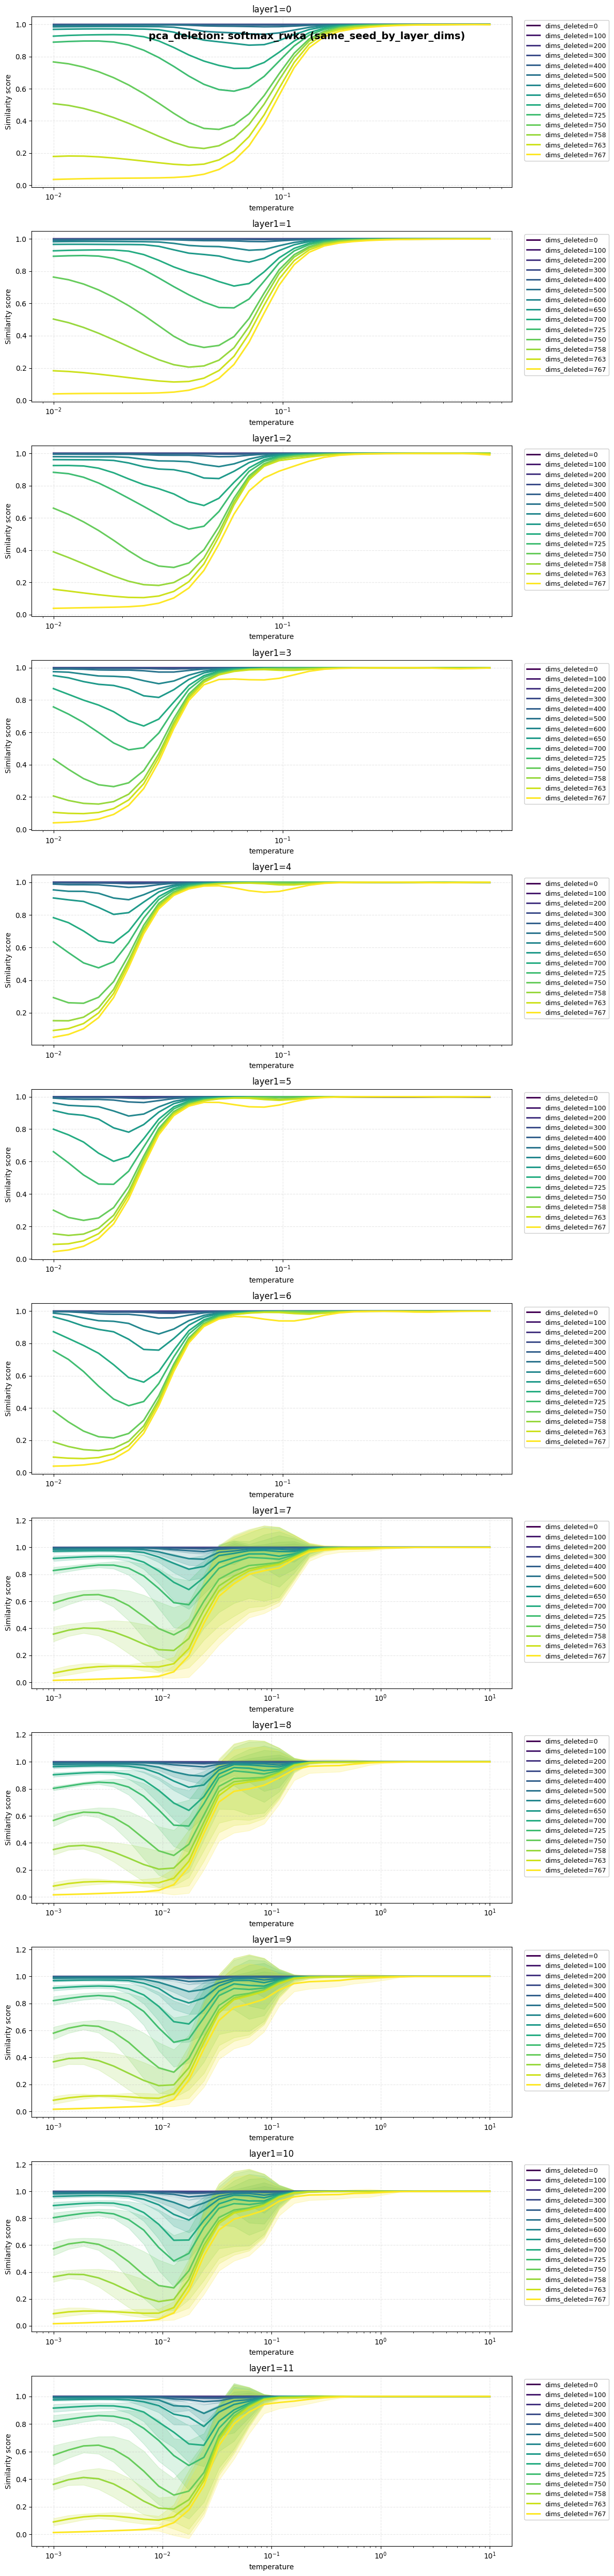

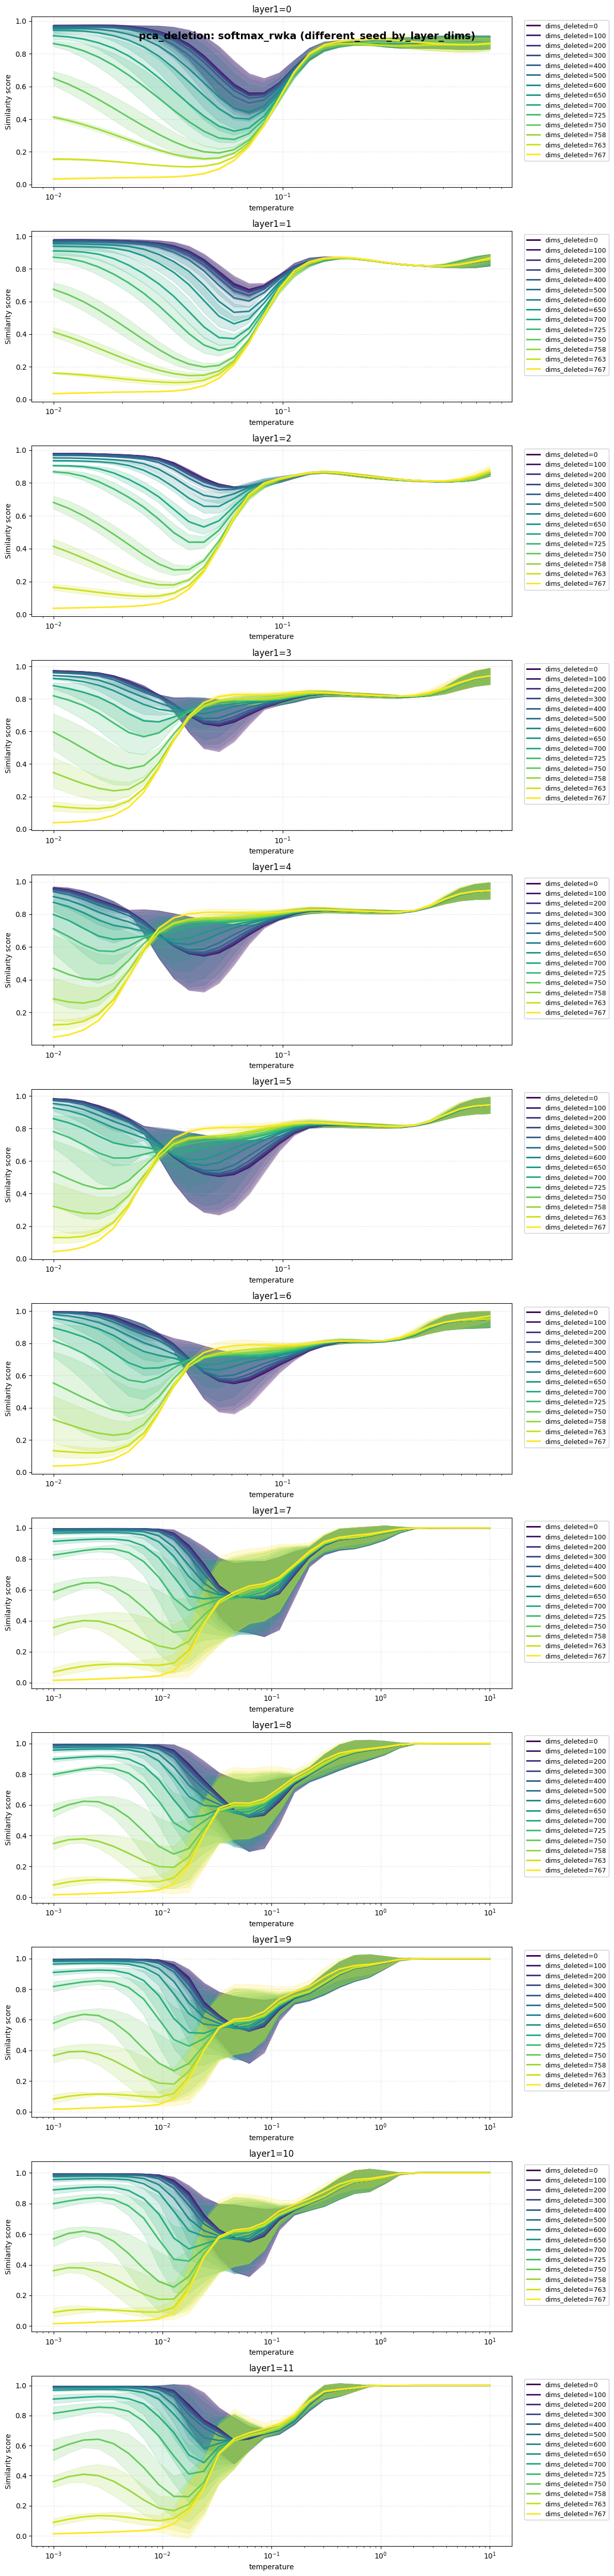

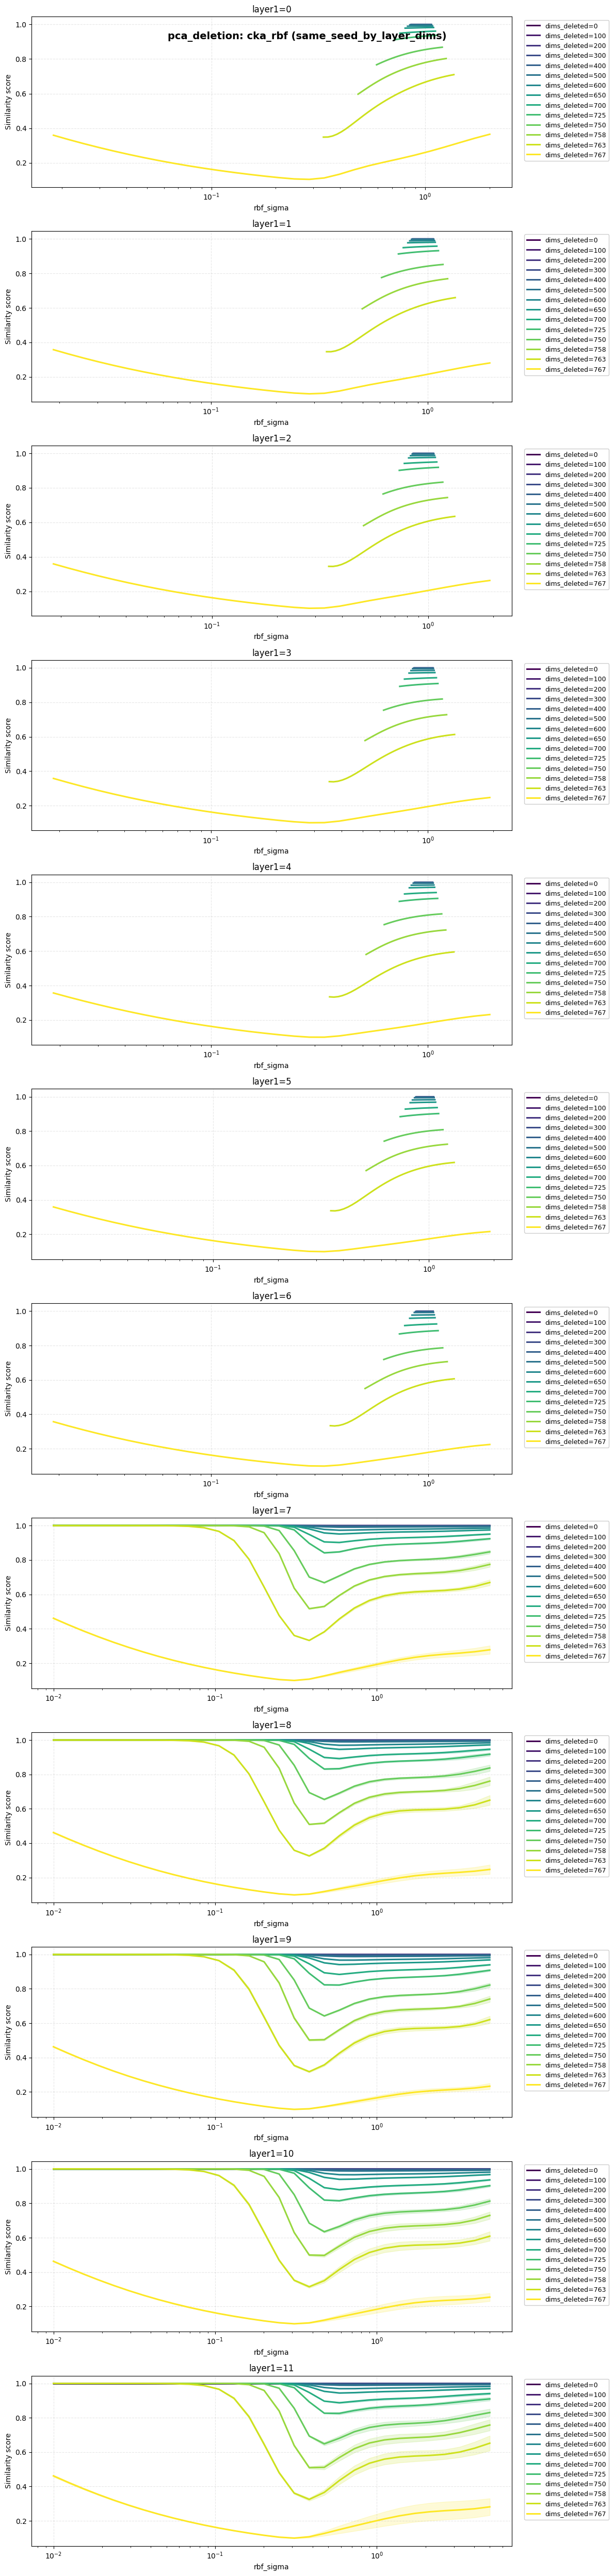

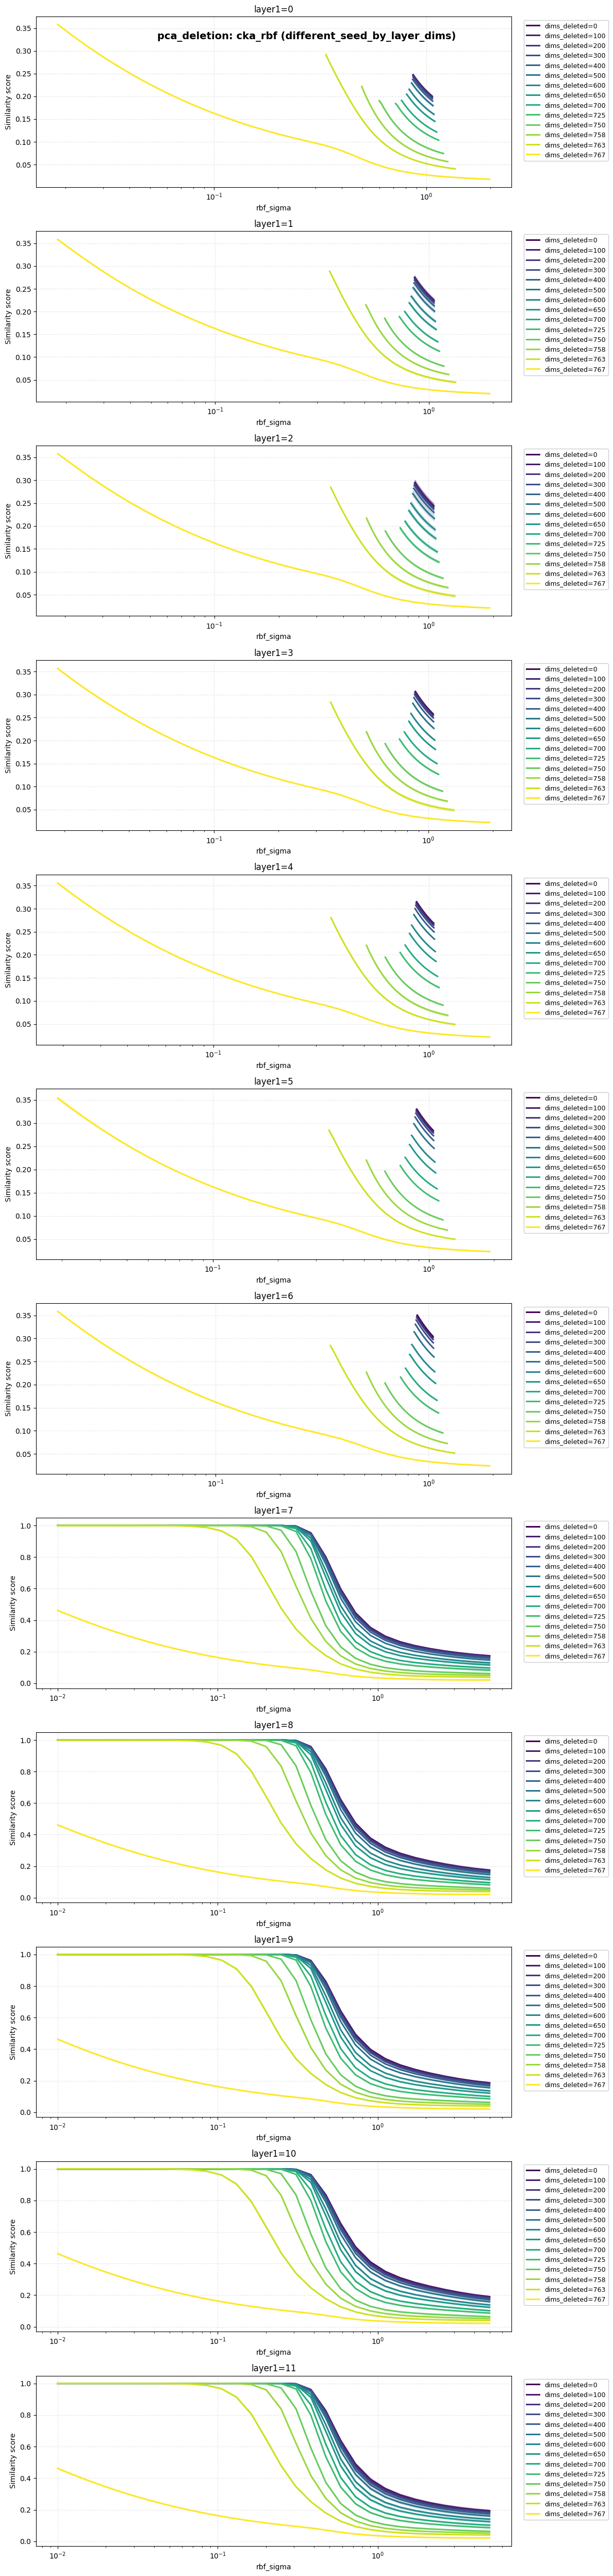

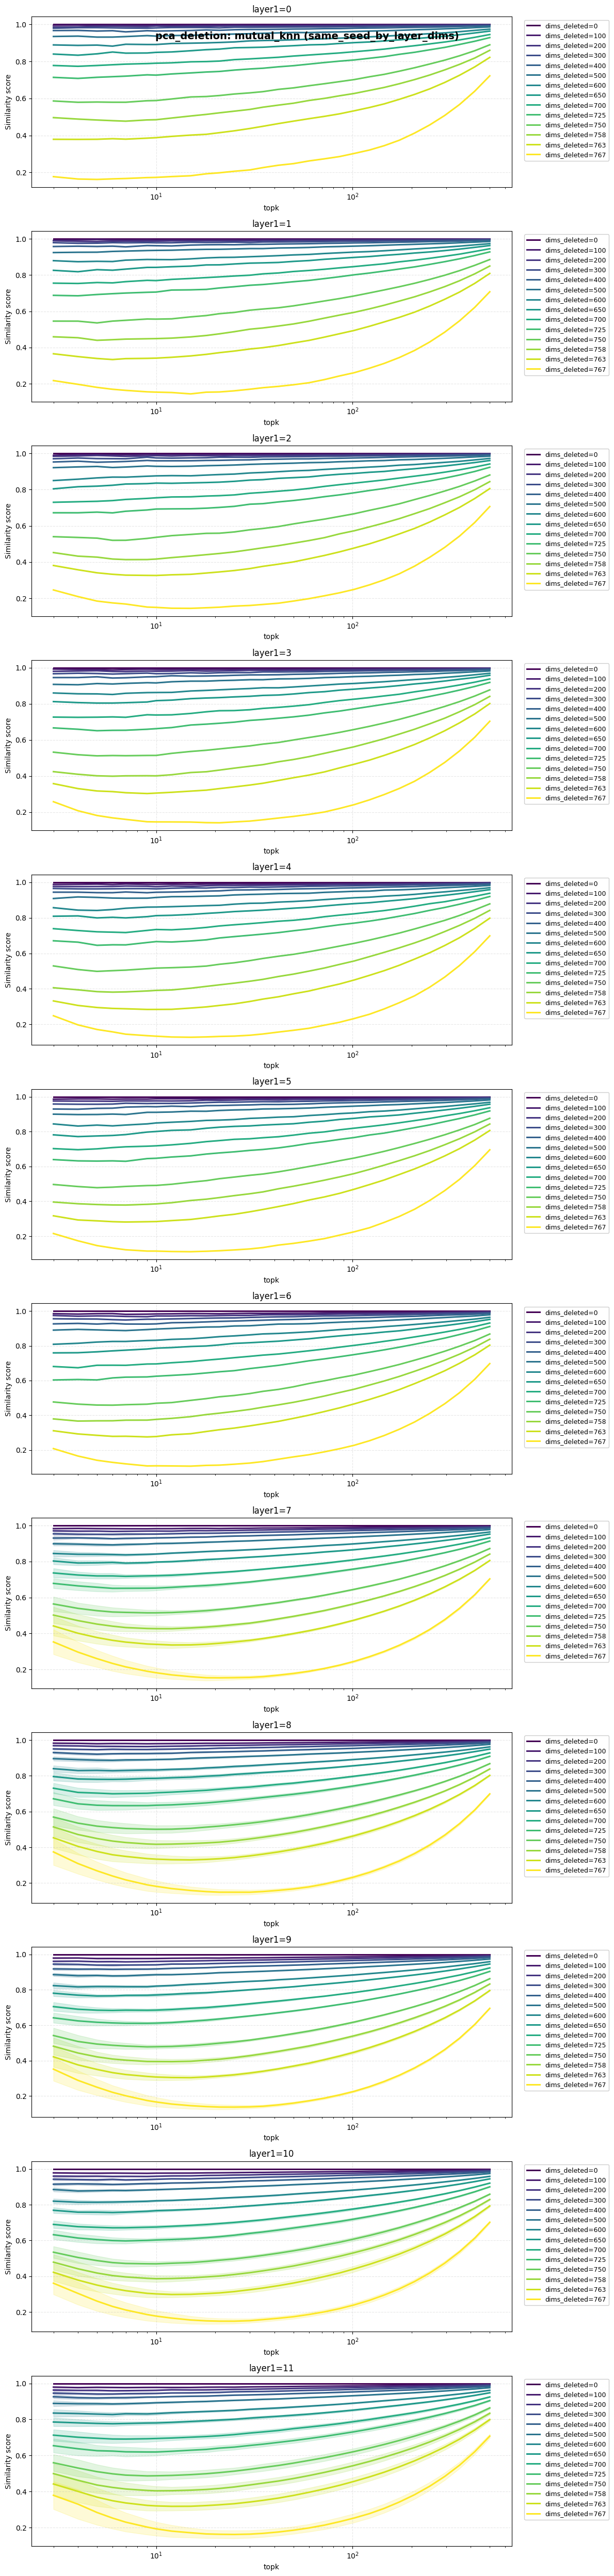

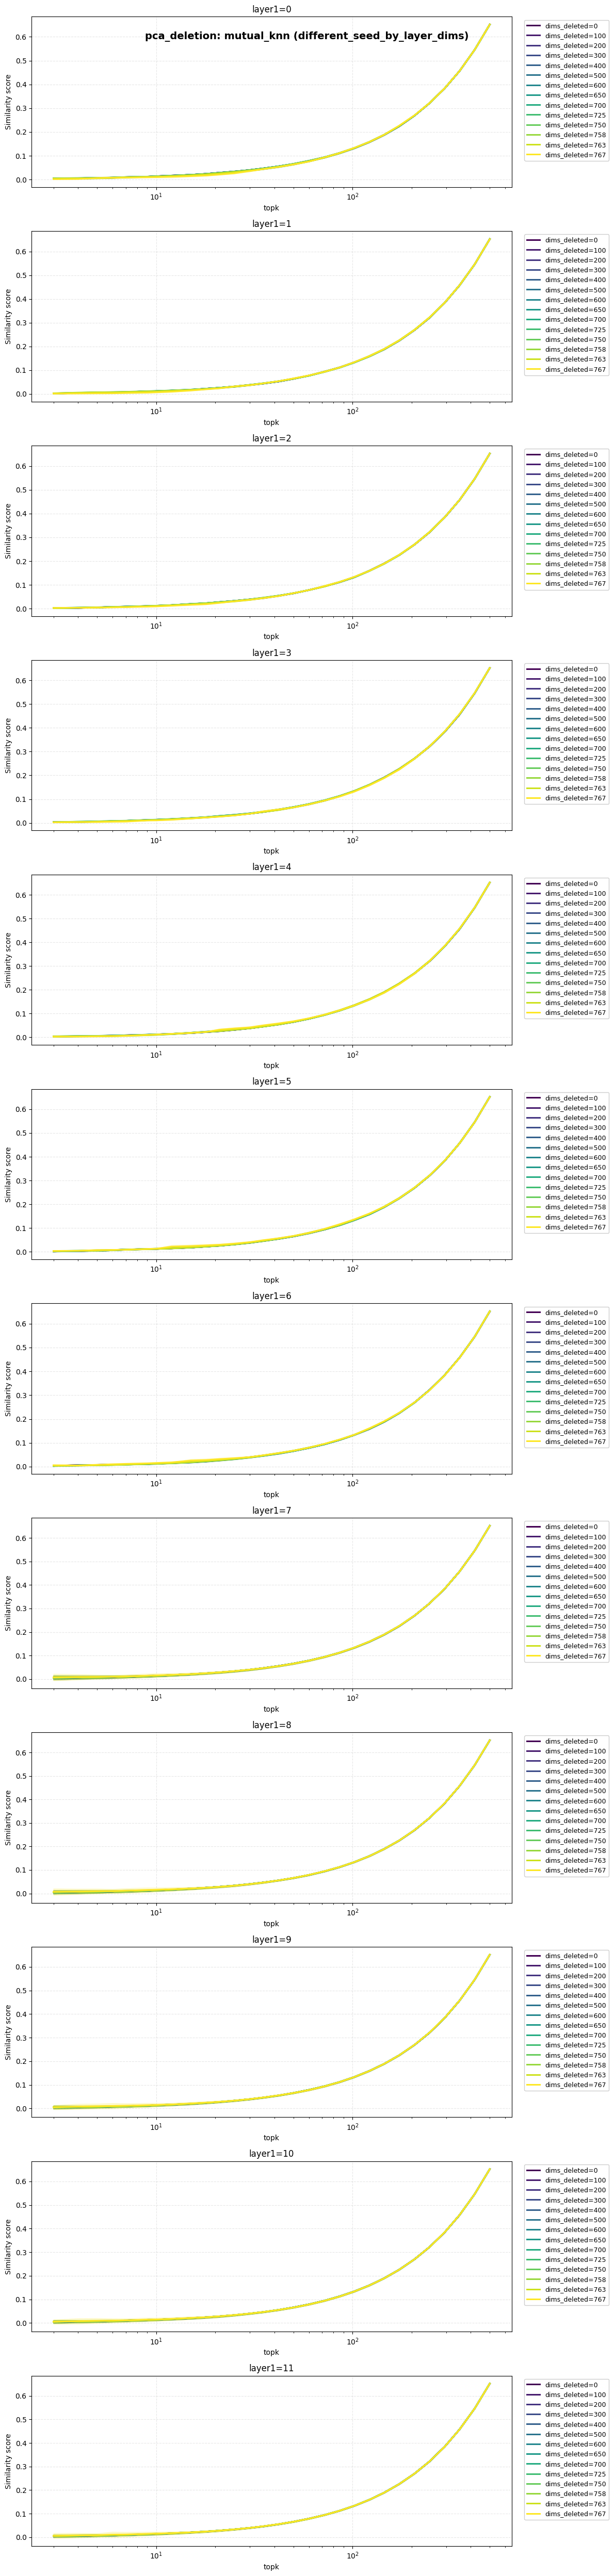

In [4]:
saved_paths = save_preset_plots(
    sweep_df,
    experiment=EXPERIMENT,
    metrics=metrics,
    figures_dir=figures_dir,
    ref_layer=REF_LAYER,
)
saved_paths

In [5]:
# Future heatmap scaffold: merge this sampled dataframe with full_df_self_computed.csv
# on representation metadata columns plus dims_deleted, then correlate similarity_at_param with task diffs.
sampled_df = sample_similarity_at_param(sweep_df, SAMPLE_PARAM, metric_name=metrics[0] if metrics else None)
sampled_df[["metric", "sampled_param", "similarity_at_param", "seed1", "seed2", "layer1", "dims_deleted"]].head()

,metric,sampled_param,similarity_at_param,seed1,seed2,layer1,dims_deleted
7470,softmax_rwka,1.0,1.000000,1,1,0,0
7471,softmax_rwka,1.0,1.000000,1,1,0,100
7472,softmax_rwka,1.0,1.000000,1,1,0,200
7473,softmax_rwka,1.0,1.000000,1,1,0,300
7474,softmax_rwka,1.0,0.999999,1,1,0,400


## PCA Deletion Baseline Figure

Recreate the paper-style plot: metric dissimilarity versus fraction of principal components deleted, with random-seed baselines shown as dashed lines.

Saved figure to /Users/barweiss/Code/grounded-repsim/sim_metric_resources/results/pca_deletion/pca_deletion_run_001/figures/sweep_signals/pca_deletion_metric_dissimilarity_baselines.png


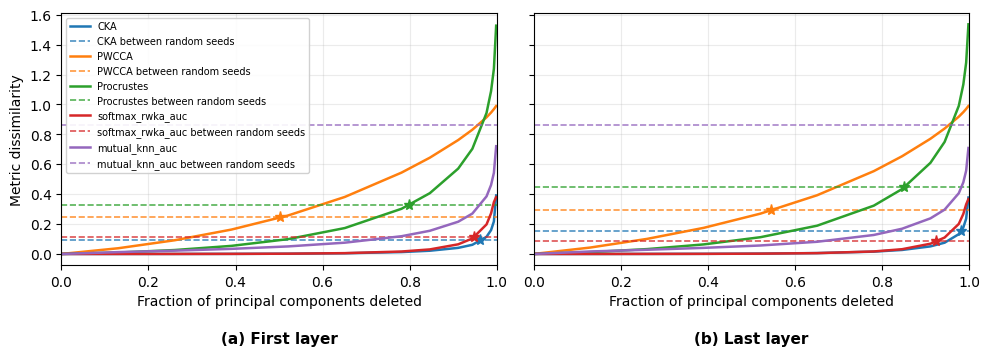

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAPER_METRICS = ["CKA", "PWCCA", "Procrustes", "softmax_rwka_auc", "mutual_knn_auc"]
PAPER_METRIC_COLORS = {
    "CKA": "tab:blue",
    "PWCCA": "tab:orange",
    "Procrustes": "tab:green",
    "softmax_rwka_auc": "tab:red",
    "mutual_knn_auc": "tab:purple",
}

full_df_path = results_path / "full_df_self_computed.csv"
if not full_df_path.exists():
    raise FileNotFoundError(f"No full dataframe found at {full_df_path}")

pca_df = pd.read_csv(full_df_path)
metrics_present = [metric for metric in PAPER_METRICS if metric in pca_df.columns]
if not metrics_present:
    raise ValueError(f"None of {PAPER_METRICS} found in {full_df_path}")

if "dims_kept" in pca_df.columns:
    total_dim = int((pca_df["dims_deleted"] + pca_df["dims_kept"]).dropna().max())
else:
    total_dim = 768

pca_df = pca_df.copy()
pca_df["fraction_deleted"] = pca_df["dims_deleted"].astype(float) / float(total_dim)
available_layers = sorted(pca_df["layer1"].dropna().unique())
LAYERS_FOR_PAPER_FIG = [available_layers[0], available_layers[-1]]
PANEL_TITLES = ["(a) First layer", "(b) Last layer"]

def metric_curve(df, metric, layer):
    subset = df[(df["layer1"] == layer) & (df["layer2"] == layer) & (df["seed1"] == df["seed2"])]
    return (
        subset.groupby("fraction_deleted", as_index=False)[metric]
        .mean()
        .sort_values("fraction_deleted")
    )

def random_seed_baseline(df, metric, layer):
    subset = df[
        (df["layer1"] == layer)
        & (df["layer2"] == layer)
        & (df["seed1"] != df["seed2"])
        & (df["dims_deleted"] == 0)
    ]
    if subset.empty:
        subset = df[(df["layer1"] == layer) & (df["layer2"] == layer) & (df["seed1"] != df["seed2"])]
    if subset.empty:
        return np.nan
    return float(subset[metric].mean())

def first_crossing(x, y, baseline):
    if np.isnan(baseline) or len(x) == 0:
        return None
    above = np.where(y >= baseline)[0]
    if len(above) == 0:
        return None
    idx = int(above[0])
    if idx == 0:
        return float(x[0]), float(y[0])
    x0, x1 = float(x[idx - 1]), float(x[idx])
    y0, y1 = float(y[idx - 1]), float(y[idx])
    if y1 == y0:
        return x1, y1
    frac = (baseline - y0) / (y1 - y0)
    return x0 + frac * (x1 - x0), baseline

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, layer, panel_title in zip(axes, LAYERS_FOR_PAPER_FIG, PANEL_TITLES):
    for metric in metrics_present:
        color = PAPER_METRIC_COLORS.get(metric)
        curve = metric_curve(pca_df, metric, layer)
        if curve.empty:
            continue
        x = curve["fraction_deleted"].to_numpy(dtype=float)
        y = curve[metric].to_numpy(dtype=float)
        baseline = random_seed_baseline(pca_df, metric, layer)

        ax.plot(x, y, color=color, linewidth=1.8, label=metric)
        if not np.isnan(baseline):
            ax.axhline(
                baseline,
                color=color,
                linestyle="--",
                linewidth=1.2,
                alpha=0.8,
                label=f"{metric} between random seeds",
            )
            crossing = first_crossing(x, y, baseline)
            if crossing is not None:
                ax.plot(crossing[0], crossing[1], marker="*", color=color, markersize=8, zorder=5)

    ax.set_title(panel_title, y=-0.34, fontsize=11, fontweight="bold")
    ax.set_xlabel("Fraction of principal components deleted")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, 1.0)

axes[0].set_ylabel("Metric dissimilarity")
axes[0].legend(fontsize=7, loc="upper left", framealpha=0.9)
fig.tight_layout()

save_path = figures_dir / "pca_deletion_metric_dissimilarity_baselines.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
print(f"Saved figure to {save_path}")
plt.show()